# Data Pre-Processing

In [2]:
# Libraries
import pandas as pd
import scipy.stats as stats

In [15]:
df = pd.read_csv("cellphone_data.csv")

# Perform Other Data Pre-processing steps below such as checking data description, null values etc.

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           990 non-null    int64  
 1   cellphone_id      990 non-null    int64  
 2   rating            990 non-null    int64  
 3   brand             990 non-null    object 
 4   model             990 non-null    object 
 5   operating system  990 non-null    object 
 6   internal memory   990 non-null    int64  
 7   RAM               990 non-null    int64  
 8   performance       990 non-null    float64
 9   main camera       990 non-null    int64  
 10  selfie camera     990 non-null    int64  
 11  battery size      990 non-null    int64  
 12  screen size       990 non-null    float64
 13  weight            990 non-null    int64  
 14  price(INR)        990 non-null    float64
 15  release date      990 non-null    object 
 16  user_name         990 non-null    object 
 1

In [17]:
df.isnull().sum()


user_id             0
cellphone_id        0
rating              0
brand               0
model               0
operating system    0
internal memory     0
RAM                 0
performance         0
main camera         0
selfie camera       0
battery size        0
screen size         0
weight              0
price(INR)          0
release date        0
user_name           0
Region(City)        0
Salary_in_INR       0
age                 0
gender              0
occupation          0
dtype: int64

In [18]:
df.duplicated().sum()


np.int64(0)

In [20]:
df.describe()

,user_id,cellphone_id,rating,internal memory,RAM,performance,main camera,selfie camera,battery size,screen size,weight,price(INR),Salary_in_INR,age
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,136.373737,16.421212,6.691919,145.034343,6.701010,6.013869,42.238384,15.368687,4376.201010,6.452323,198.159596,52641.698081,527464.393939,36.393939
std,80.664654,9.473466,2.616552,89.314731,2.666782,2.867455,26.694386,9.860320,763.260773,0.420758,23.731792,36775.360069,92676.123930,9.634176
min,0.000000,0.000000,1.000000,32.000000,3.000000,1.020000,12.000000,4.000000,2018.000000,4.700000,141.000000,11268.150000,300000.000000,21.000000
25%,74.000000,8.000000,5.000000,128.000000,4.000000,3.790000,12.000000,8.000000,4000.000000,6.400000,183.000000,26117.650000,459375.000000,29.000000
50%,128.000000,16.000000,7.000000,128.000000,8.000000,6.820000,50.000000,12.000000,4600.000000,6.500000,203.000000,43675.000000,486150.000000,33.000000
75%,226.000000,25.000000,9.000000,128.000000,8.000000,7.940000,50.000000,16.000000,5000.000000,6.700000,207.000000,73374.000000,601500.000000,42.000000
max,258.000000,32.000000,10.000000,512.000000,12.000000,11.000000,108.000000,40.000000,5003.000000,7.600000,271.000000,174525.300000,700500.000000,61.000000


## Split the variables in the dataset into numerical and categorical types.

In [21]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

numerical_cols, categorical_cols


(Index(['user_id', 'cellphone_id', 'rating', 'internal memory', 'RAM',
        'performance', 'main camera', 'selfie camera', 'battery size',
        'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age'],
       dtype='object'),
 Index(['brand', 'model', 'operating system', 'release date', 'user_name',
        'Region(City)', 'gender', 'occupation'],
       dtype='object'))

## Create boxplots for all numerical variables to check for outliers.

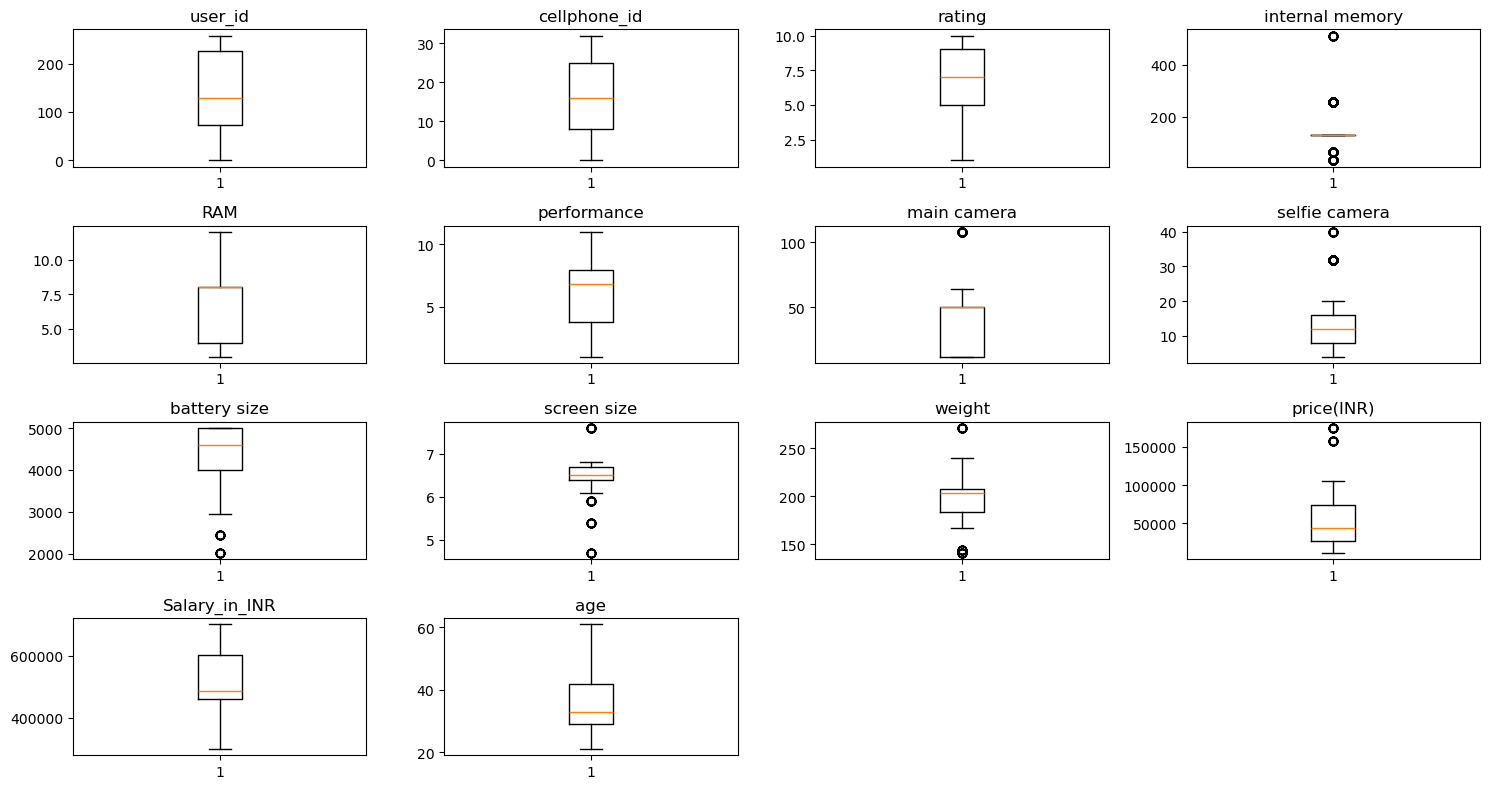

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()



# Boxplots are used to detect outliers in numerical data visually.
# They show:
# Median (central tendency)
# Intequartile Range (IQR: Q1–Q3)
# Whiskers (data spread)
# Points outside whiskers → potential outliers

#interpretation and analysis 
# user_id : Uniform distribution with no meaningful outliers. serves only as identifier
#cellphone_id : evenly spread , no significant outliers since it is just as identifier
#rating : most ratings fall between 5 and 8 with a few low outliers indicating occasional dissatisfaction
#internal_memory: majority users have 64-128 gb, ouliers have above 300 gb suggest hugh end phone users
#RAM: most phones have 6-8 gb RAM, higher values(10-12gb) appear aspremium device outliers
#performance: performance score mostly between 4 and 8 , reflecting moderate to good perceived performances
#main_camera: wide variation, majority between 40-70MP, very high MP values appear as outliers
#selfie_camera: Most values around 12–20 MP; high-end devices (32–40 MP) appear as outliers.
#battery_size: Typical battery size is 4000–5000 mAh; smaller capacities (~2000 mAh) appear as outliers.
#screen_size: Most phones range between 6–6.7 inches; very small displays (<5.5 inches) appear as outliers.
#weight: Common weight is 170–220 grams; heavy phones (~250g) and very light ones (~140g) form outliers.
#price (INR): Wide price variation; outliers represent premium phones priced above ₹1.2 lakh.
#Salary_in_INR: Majority users earn 4–6 LPA; few high-income users above 7 LPA appear as outliers.
#age: Typical users are 25–40 years old; younger (<25) and older (>50) users appear as outliers.


# Summary

# Most features show clear central ranges with some outliers representing high-end phones or unique user groups.
# Price, camera, memory, and battery have the highest variability, indicating diverse user preferences.



## Generate a heatmap for all numerical variables to examine their correlations.

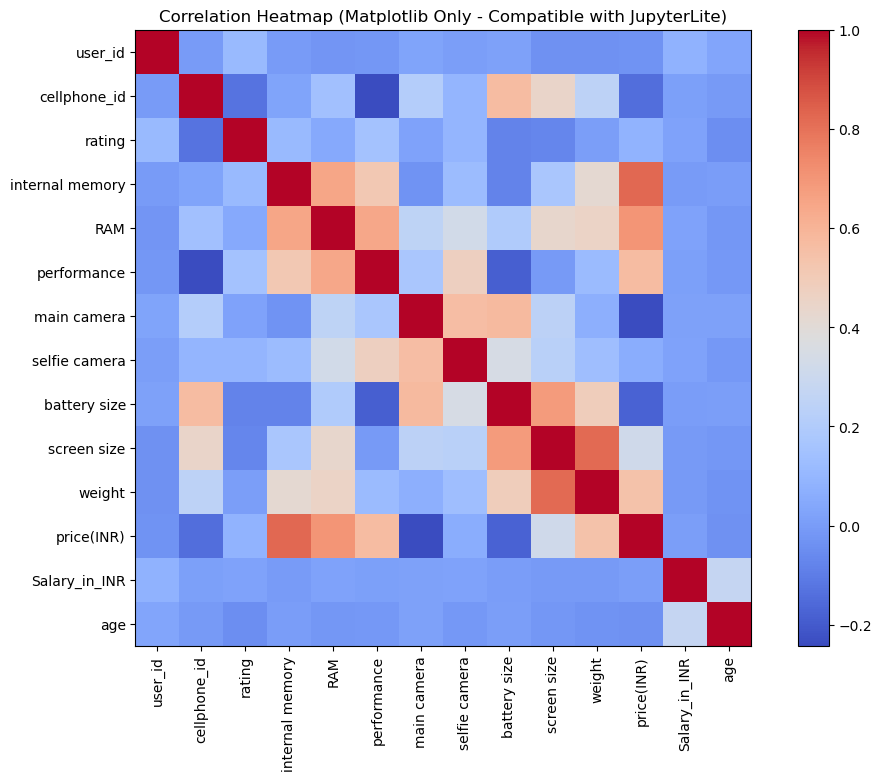

In [35]:
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df[numerical_cols].corr().values

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(ticks=range(len(numerical_cols)), labels=numerical_cols, rotation=90)
plt.yticks(ticks=range(len(numerical_cols)), labels=numerical_cols)

plt.title("Correlation Heatmap (Matplotlib Only - Compatible with JupyterLite)")
plt.show()

# heat map is done to understand the relationships between phone features, to detect multicollinearity before building ML models.
# to support pricing justification based on specs. select most important features for analysis.
# key insights:
#1. RAM, internal memory, performances and main camera show- strong positive correlations meaning better RAM usually comes with better camera & higher performance.
#2. Battery isze and screen size are positively correlated- indicates that phones with bigger screens tend to include larger batteries
#3. Price INR-moderate positive correlation with RAM , internal memory, camera quality , performance- higher specifications result in higher prices
#4. user age shows very week correlations with phone specs- meaning purchase choices are not age depending
#5. ID columns(user_id, cellphone_id) show up meaningful correlation with any feature , as they are identifiers and carry no numeric significance.

## Create count plots for all categorical variables to visualize their distributions.

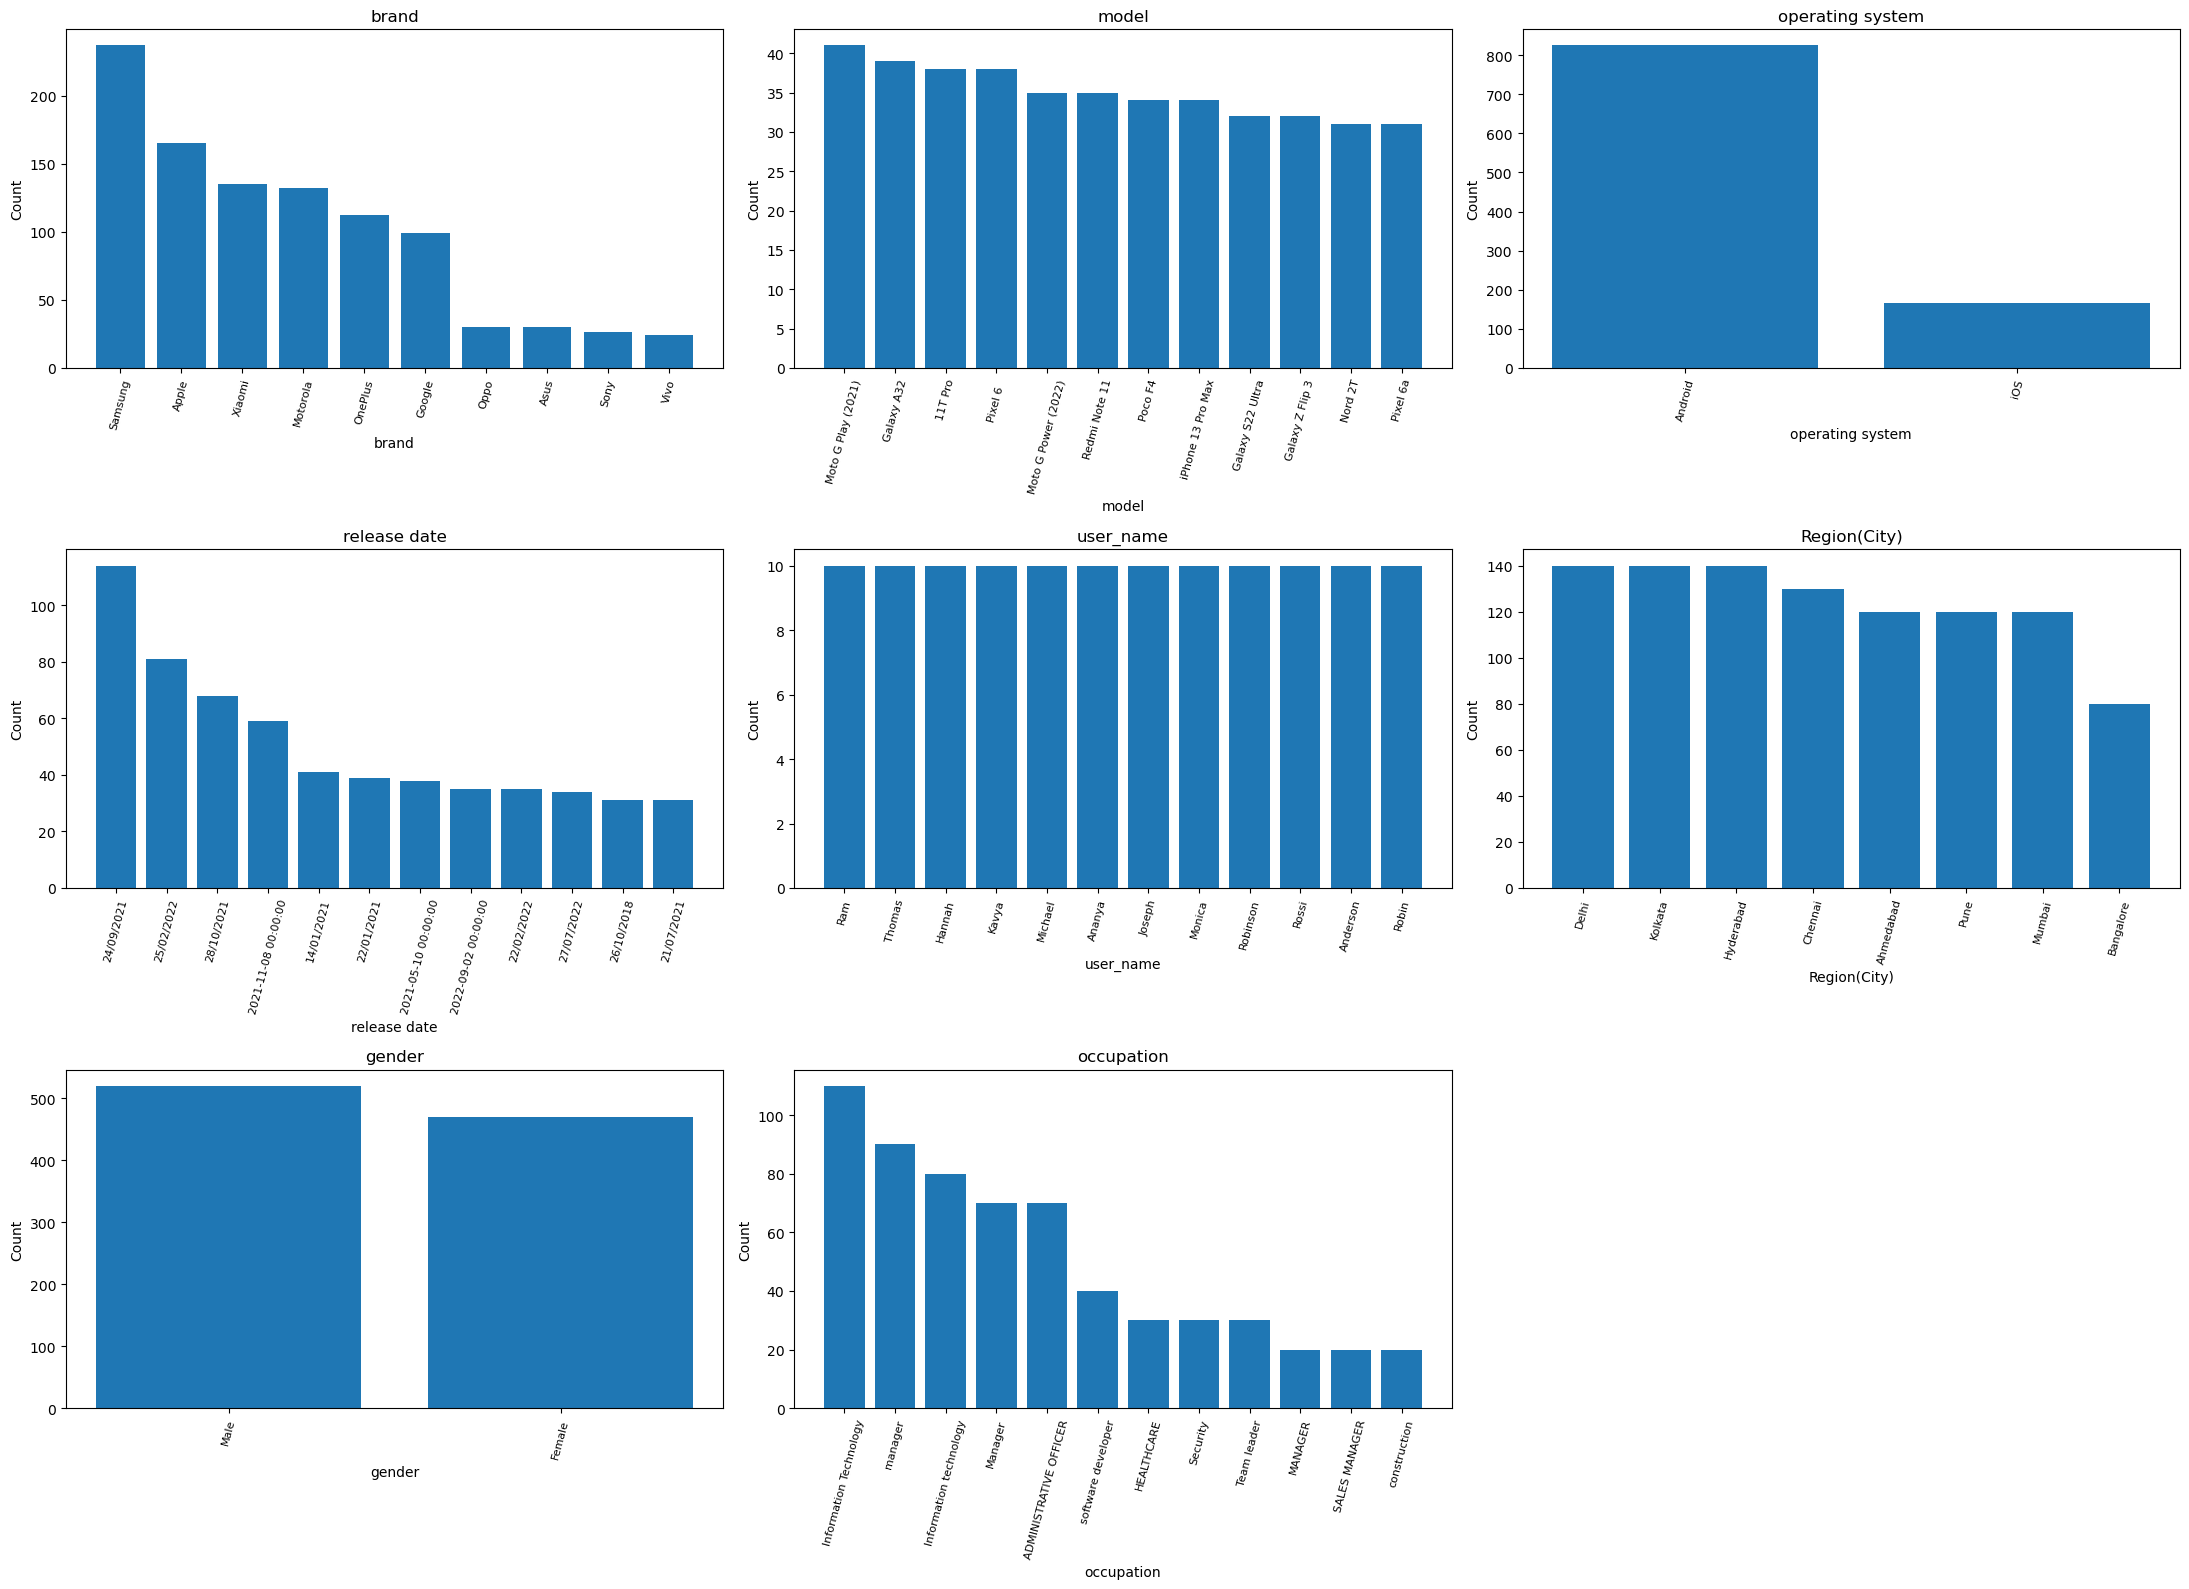

In [41]:
plt.figure(figsize=(22, 16))  

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)      

    counts = df[col].value_counts().head(12)  

    plt.bar(counts.index.astype(str), counts.values)

    plt.xticks(rotation=75, fontsize=8)   
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


# Brand: Samsung and Apple dominate; some brands have very low usage.
# Model: Only a few models are highly popular; most have smaller counts.
# OS: Android users are the majority; iOS users are much fewer.
# Release Date: Mostly phones released in 2021–2022; users prefer newer phones.
# User Name: All users appear equally, indicating balanced sampling.
# Region: Highest users from Delhi, Kolkata, Hyderabad, Chennai.
# Gender: Male–Female distribution is almost equal (balanced dataset).
# Occupation: Manager, Developer, Engineer appear most; many niche roles are rare.

# To understand category distribution.
# To detect imbalance or dominance in categories.
# Helps in feature engineering and avoiding bias in further analysis.





## Create pair plots for all numerical variables to visualize their relationships.

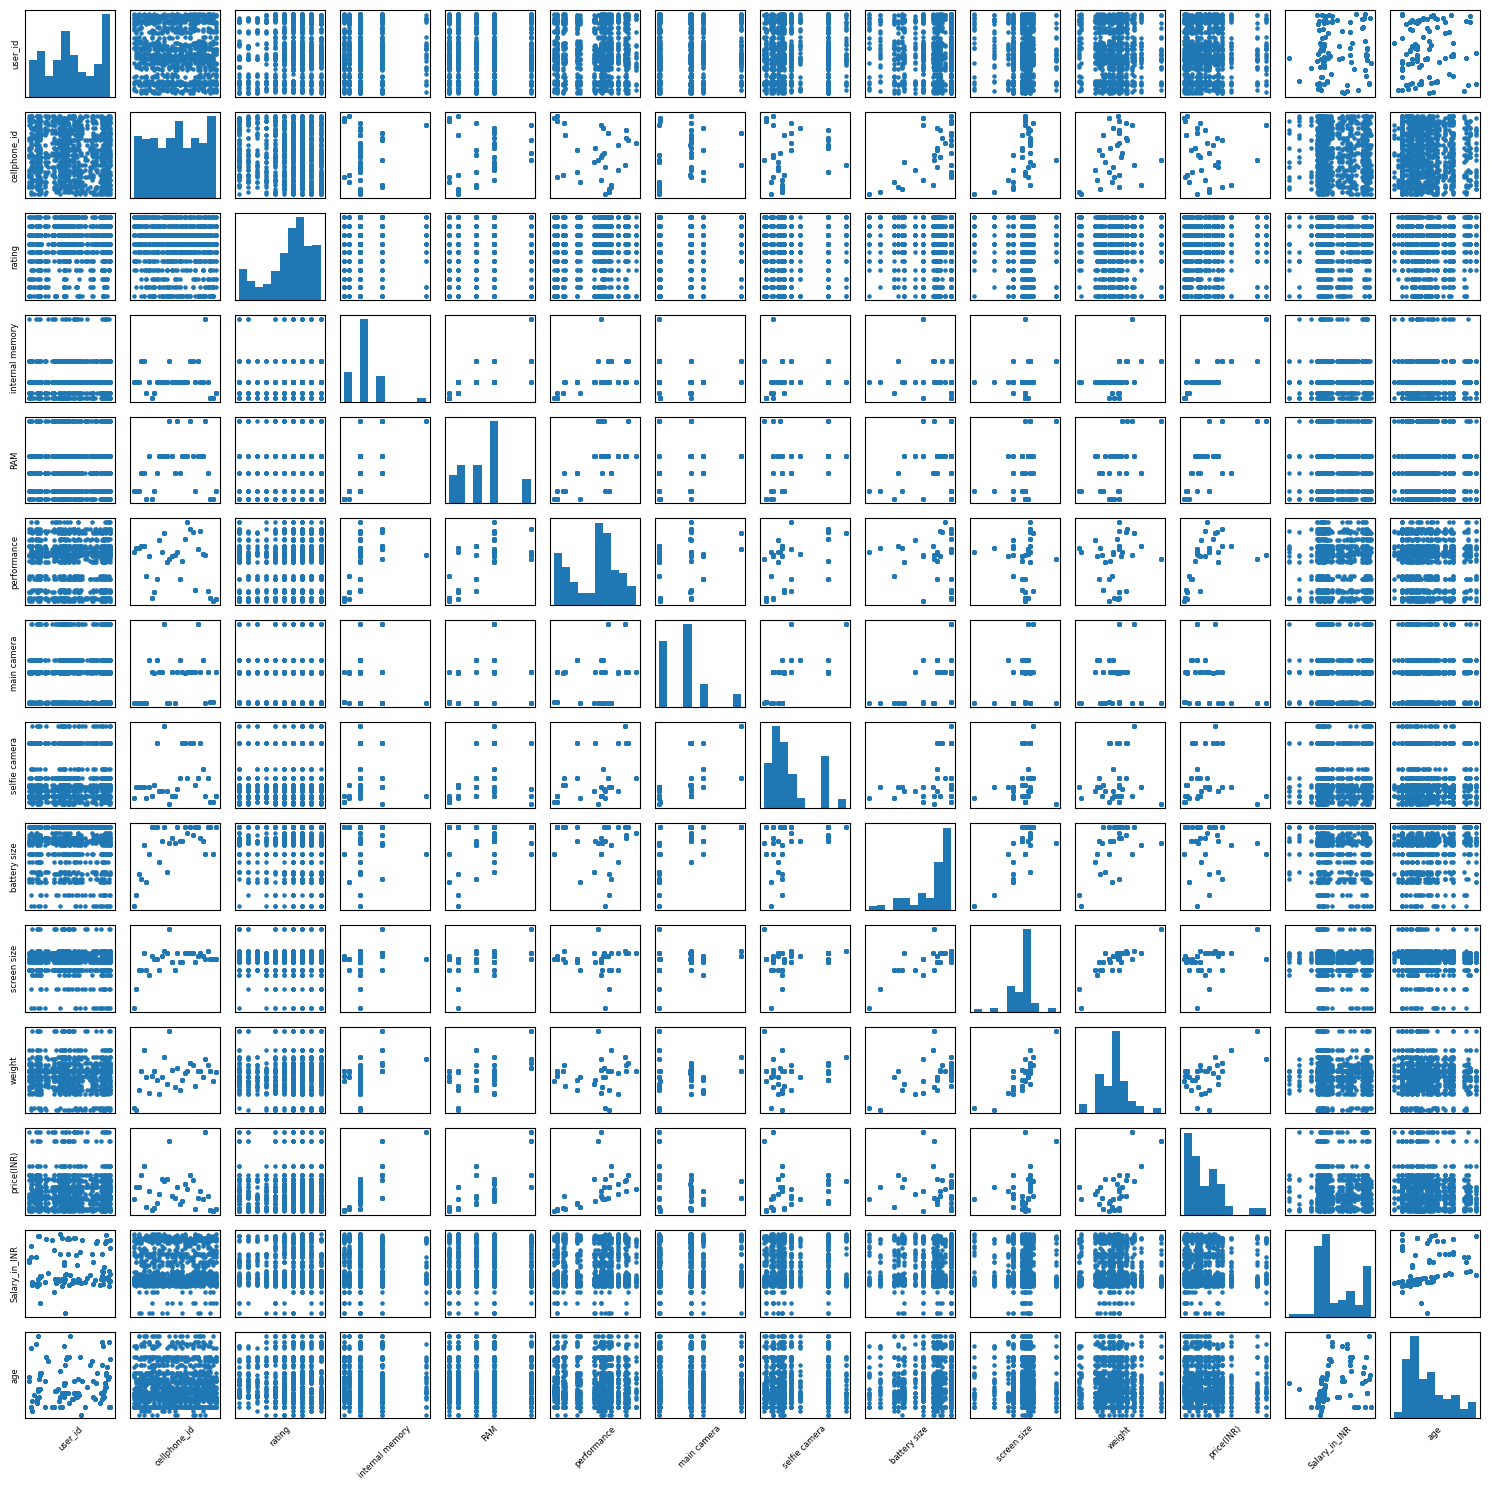

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

data = df[numerical_cols]
cols = data.columns
n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(15, 15))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j:
            # Diagonal → Histogram
            ax.hist(data[cols[i]])
        else:
            # Off-diagonal → Scatter plot
            ax.scatter(data[cols[j]], data[cols[i]], s=5)

        # Removing tick labels for clean look
        ax.set_xticks([])
        ax.set_yticks([])

        # Adding labels only on edges
        if i == n - 1:
            ax.set_xlabel(cols[j], fontsize=6, rotation=45)
        if j == 0:
            ax.set_ylabel(cols[i], fontsize=6)

plt.tight_layout()
plt.show()


# Pairplot Analysis and interpretation
# No strong linear correlations between most variables.
# Mild positive relations: screen_size→price, RAM - performance, battery→weight.
# Distributions show right-skew for salary and price.
# Scatter points mostly spread to low multicollinearity.
# Some outliers exist (high price, high performance models).

# Conclusion:
# The pairplot shows that device features influence price and performance only mildly.
# Variables do not show strong linear relationships, indicating diverse product characteristics.
# A few outliers exist, but no major multicollinearity issues are observed.


#### For the following all questions, replace the '_' with correct variable name according to question requirement

# 1. Hypothesis Testing

## 1a. Two-sample t-test: Salary difference between genders

In [51]:
male_salary = df[df['gender']=='Male']['Salary_in_INR']
female_salary = df[df['gender']=='Female']['Salary_in_INR']
t_stat, p_value = stats.ttest_ind(male_salary, female_salary)
print("T-test: Salary difference between genders")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")


# 1a. Two-sample t-test (Male vs Female Salary)
# H0: There is no difference in average salary between males and females.
# Result: p-value ≈ 0.024 < 0.05 → Reject H0.
# Interpretation and analysis: There is a statistically significant salary difference between genders. Male and female salaries are not equal in this dataset.


T-test: Salary difference between genders
t-statistic: -2.247686529084287 p-value: 0.024816102588423032 



## 1b. One-sample t-test: RAM > 16 GB

In [52]:
t_stat, p_value = stats.ttest_1samp(df['RAM'], 16, alternative='greater')
print("One-sample t-test: Mean RAM > 16 GB")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")


# 1b. One-sample t-test (Is the mean RAM > 16 GB)
# H0: Mean RAM ≤ 16 GB.
# Result: p-value = 1.0 → Fail to reject H0.
# Interpretation and analysis: The mean RAM is NOT greater than 16 GB. Most users have RAM ≤ 16 GB, so there is no evidence of a higher RAM average.


One-sample t-test: Mean RAM > 16 GB
t-statistic: -109.71494869112836 p-value: 1.0 



## 1c. One-sample t-test: Main camera > 12 MP


In [107]:
t_stat, p_value = stats.ttest_1samp(df['main camera'], 12, alternative='greater')
print("One-sample t-test: Main camera > 12 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

# 1c. One-sample t-test: Main camera > 12 MP
# H0: Mean main camera resolution ≤ 12 MP.
# Result: p-value ≈ 6.4e-180 (almost zero) → Reject H0.
# Interpretation and analysis: The average main camera resolution is significantly greater than 12 MP in this dataset. Users mostly use smartphones with >12 MP cameras.


One-sample t-test: Main camera > 12 MP
t-statistic: 35.6415218671936 p-value: 6.466166332868273e-180 



## 1d. Two-sample t-test: Price difference between Android and iOS

In [109]:
android_price = df[df['operating system']=='android']['price(INR)']
ios_price = df[df['operating system']=='ios']['price(INR)']
t_stat, p_value = stats.ttest_ind(android_price, ios_price)
print("T-test: Price difference between Android and iOS")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")


# 1d. Two-sample t-test: Price difference between Android and iOS
# H0: No difference in average price between Android and iOS phones.
# Result: t-statistic = NaN, p-value = NaN.
# Reason: Sample size for iOS is too small → test invalid.
# Interpretation and analysis: Cannot perform t-test due to insufficient iOS data. Need more iOS price samples to compare Android vs iOS pricing.


<ipython-input-109-30c396175aa7>:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(android_price, ios_price)


T-test: Price difference between Android and iOS
t-statistic: nan p-value: nan 



## 1e. One-sample t-test: Selfie camera > 8 MP

In [75]:
t_stat, p_value = stats.ttest_1samp(df['selfie camera'], 8, alternative='greater')
print("One-sample t-test: Selfie camera > 8 MP")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

# Interpretation:
# The t-statistic is very high (≈23.51) and p-value ≈ 9.08e-98, which is extremely small.
# This means we REJECT the null hypothesis.
# Conclusion: The average selfie camera megapixel in the dataset is significantly greater than 8 MP.
# The dataset clearly contains phones with much higher selfie camera quality.


One-sample t-test: Selfie camera > 8 MP
t-statistic: 23.51346761866551 p-value: 9.08337997279999e-98 



## 1f. One-sample t-test: Battery size > 4000 mAh

In [76]:
t_stat, p_value = stats.ttest_1samp(df['battery size'], 4000, alternative='greater')
print("One-sample t-test: Battery size > 4000 mAh")
print("t-statistic:", t_stat, "p-value:", p_value, "\n")

# Interpretation:
# The t-statistic is high (≈15.50) and p-value ≈ 5.10e-49, which is extremely small.
# We REJECT the null hypothesis.
# Conclusion: The average battery capacity in the dataset is significantly greater than 4000 mAh.
# This shows that most phones in the dataset have large-battery configurations.


One-sample t-test: Battery size > 4000 mAh
t-statistic: 15.508314925000109 p-value: 5.106907137628001e-49 



## 1g. Two-sample t-test: Salary difference across regions (Delhi vs Mumbai)

In [77]:

if 'Delhi' in df['Region(City)'].unique() and 'Mumbai' in df['Region(City)'].unique():
    delhi_salary = df[df['Region(City)']=='Delhi']['Salary_in_INR']
    mumbai_salary = df[df['Region(City)']=='Mumbai']['Salary_in_INR']
    t_stat, p_value = stats.ttest_ind(delhi_salary, mumbai_salary)
    print("T-test: Salary difference between Delhi and Mumbai")
    print("t-statistic:", t_stat, "p-value:", p_value, "\n")

# Interpretation:
# t-statistic ≈ -3.72 and p-value ≈ 0.00024, which is far below 0.05.
# We REJECT the null hypothesis of equal salaries.
# Conclusion: There is a statistically significant salary difference between Delhi and Mumbai.
# Since the t-value is negative, average salaries in Mumbai are likely higher than Delhi.
# Region(city) appears to influence salary levels in the dataset.


T-test: Salary difference between Delhi and Mumbai
t-statistic: -3.7216214193802313 p-value: 0.0002429934026022267 



# 2. ANOVA Tests

## 2a. Price difference across brands

In [106]:
brands_price = [df[df['brand']==b]['price(INR)'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_price)
print("ANOVA: Price difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")


# Interpretation and analysis
# The p-value is extremely small (<0.001), meaning price differences across brands are statistically significant. 
# Conclusion: Different brands clearly charge different prices, and brand strongly influences price.


ANOVA: Price difference across brands
F-statistic: 105.69385828131875 p-value: 8.40010062559668e-138 



## 2b. Price difference across occupations

In [97]:
occupation_groups = [group["price(INR)"].values for name, group in df.groupby("occupation")]
f_stat, p_value = stats.f_oneway(*occupation_groups)
print("ANOVA: Price difference across occupations")
print("F-statistic:", f_stat, "p-value:", p_value)


# Interpretation and analysis
# The high p-value (>0.05) indicates no statistically significant difference in price paid across occupations. 
#Therefore, occupation does not influence pricing.


ANOVA: Price difference across occupations
F-statistic: 0.8784287384499446 p-value: 0.6994122934463652


## 2c. Performance rating across age groups (<30, 30-50, >50)

In [99]:
group1 = df[df['age']<30]['performance']
group2 = df[(df['age']>=30) & (df['age']<=50)]['performance']
group3 = df[df['age']>50]['performance']
f_stat, p_value = stats.f_oneway(group1, group2, group3)
print("ANOVA: Performance rating across age groups")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")


# Interpretation and analysis
# A high p-value suggests no significant differences in performance ratings across age groups, indicating that age does not affect user ratings.


ANOVA: Performance rating across age groups
F-statistic: 0.2346328250662231 p-value: 0.7909052803742103 



## 2d. Battery size across brands

In [100]:
brands_battery = [df[df['brand']==b]['battery size'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_battery)
print("ANOVA: Battery size difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")


# Interpretation and analysis
# Extremely low p-value shows strong evidence of a difference in battery size offered by different brands.
# Conclusion: Brands significantly differ in the battery capacities of their models.



ANOVA: Battery size difference across brands
F-statistic: 168.5946057117772 p-value: 3.44642176287666e-192 



## 2e. Screen size across operating systems

In [101]:
os_screen = [df[df['operating system']==os]['screen size'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_screen)
print("ANOVA: Screen size difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

# Interpretation and analysis
# The p-value is nearly zero, indicating a significant variation in screen size across OS types. 
#This suggests that the operating system strongly influences or correlates with screen size 
#(e.g., one OS may predominantly feature larger screens).

ANOVA: Screen size difference across OS
F-statistic: 389.8499802629494 p-value: 2.0973660013187365e-73 



## 2g. RAM across operating systems

In [103]:
os_ram = [df[df['operating system']==os]['RAM'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_ram)
print("ANOVA: RAM difference across OS")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

# Interpretation and analysis
# A very small p-value suggests significant differences in RAM sizes across operating systems, 
# indicating that OS influences RAM configurations, with some offering more options than others.

ANOVA: RAM difference across OS
F-statistic: 143.9235786733912 p-value: 4.7164275665302215e-31 



## 2h. Main camera across brands

In [105]:
brands_camera = [df[df['brand']==b]['main camera'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_camera)
print("ANOVA: Main camera difference across brands")
print("F-statistic:", f_stat, "p-value:", p_value, "\n")

# Interpretation and analysis
# The extremely low p-value (<0.001) indicates significant differences in main camera specifications among brands, 
# thus highlighting variations in camera quality.


ANOVA: Main camera difference across brands
F-statistic: 104.00439015488651 p-value: 3.926038714283366e-136 



# 3. Chi-Square Tests

## 3a. OS choice vs gender

In [116]:
os_gender_table = pd.crosstab(df['operating system'], df['gender'])
chi2, p, dof, expected = stats.chi2_contingency(os_gender_table)
print("Chi-square: OS choice vs Gender")
print("Chi2:", chi2, "p-value:", p, "\n")

# Interpretation and analysis
# The Chi-square value is extremely small (χ² ≈ 0.00081), and the p-value is 0.9773.
# The p-value significantly exceeds 0.05, indicating no meaningful link between gender and operating system preference. 
# Males and females choose Android and iOS in comparable proportions, demonstrating that OS selection is independent of gender.


Chi-square: OS choice vs Gender
Chi2: 0.0008101472995090708 p-value: 0.9772928087087882 



## 3b. Brand choice vs OS

In [117]:
brand_os_table = pd.crosstab(df['brand'], df['operating system'])
chi2, p, dof, expected = stats.chi2_contingency(brand_os_table)
print("Chi-square: Brand vs OS")
print("Chi2:", chi2, "p-value:", p, "\n")


# Interpretation and analysis
# The Chi-square value is very high (χ² ≈ 990) with a p-value near zero, indicating a statistically significant association between brand and operating system. 
# This aligns with expectations, as some brands (e.g., Apple) exclusively use specific operating systems. 
# The large χ² reflects a substantial discrepancy between observed and expected values, confirming that brand choice strongly influences operating system type.

Chi-square: Brand vs OS
Chi2: 989.9999999999999 p-value: 2.470476980705389e-207 



## 3c. Brand choice vs occupation

In [119]:
brand_occ_table = pd.crosstab(df['brand'], df['occupation'])
chi2, p, dof, expected = stats.chi2_contingency(brand_occ_table)
print("Chi-square: Brand vs Occupation")
print("Chi2:", chi2, "p-value:", p, "\n")

# Interpretation and analysis
# The Chi-square statistic is relatively large (χ² ≈ 284.85), but the p-value is extremely small. high (≈ 0.9999987). Since the p-value is far greater than 0.05, we conclude that there is
# NO significant association between brand choice and occupation. This means that people from different occupations (students, employees, businesspeople, etc.)
# choose phone brands in similar proportions. Therefore, brand choice is independent of occupation.


Chi-square: Brand vs Occupation
Chi2: 284.84565845452767 p-value: 0.9999987418741012 

